# Libraries

In [ ]:
# Data handling
import pandas as pd
import numpy as np

# Text processing
import re
import nltk
from nltk.corpus import stopwords
from nltk.stem import WordNetLemmatizer
from nltk.tokenize import word_tokenize

# Visualization
import matplotlib.pyplot as plt
import seaborn as sns
from wordcloud import WordCloud
from gensim.models import Word2Vec

# Machine Learning
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import LabelEncoder
from sklearn.feature_extraction.text import CountVectorizer, TfidfVectorizer
from sklearn.linear_model import LogisticRegression
from sklearn.tree import DecisionTreeClassifier
from sklearn.ensemble import RandomForestClassifier
from sklearn.svm import LinearSVC
from sklearn.naive_bayes import MultinomialNB, BernoulliNB
from xgboost import XGBClassifier  
from sklearn.decomposition import PCA

# Evaluation
from sklearn.metrics import (
    accuracy_score,
    classification_report,
    confusion_matrix,
    f1_score
)

# Save model
import pickle  
import joblib
nltk.download('punkt')
nltk.download('stopwords')
nltk.download('wordnet')
nltk.download('omw-1.4')

print("\n All libraries imported successfully!")


 All libraries imported successfully!


[nltk_data] Downloading package punkt to C:\Users\Windows 11-Pro
[nltk_data]     Edu\AppData\Roaming\nltk_data...
[nltk_data]   Package punkt is already up-to-date!
[nltk_data] Downloading package stopwords to C:\Users\Windows 11-Pro
[nltk_data]     Edu\AppData\Roaming\nltk_data...
[nltk_data]   Package stopwords is already up-to-date!
[nltk_data] Downloading package wordnet to C:\Users\Windows 11-Pro
[nltk_data]     Edu\AppData\Roaming\nltk_data...
[nltk_data]   Package wordnet is already up-to-date!
[nltk_data] Downloading package omw-1.4 to C:\Users\Windows 11-Pro
[nltk_data]     Edu\AppData\Roaming\nltk_data...
[nltk_data]   Package omw-1.4 is already up-to-date!


# Load dataset

In [2]:
df = pd.read_csv("twitter_training.csv")
df.head()

,2401,Borderlands,Positive,"im getting on borderlands and i will murder you all ,"
0,2401,Borderlands,Positive,I am coming to the borders and I will kill you...
1,2401,Borderlands,Positive,im getting on borderlands and i will kill you ...
2,2401,Borderlands,Positive,im coming on borderlands and i will murder you...
3,2401,Borderlands,Positive,im getting on borderlands 2 and i will murder ...
4,2401,Borderlands,Positive,im getting into borderlands and i can murder y...


In [3]:
df.shape

(74681, 4)

# Re-name the features

In [4]:
df = df.rename(columns={"2401":"tweet_id"})
df = df.rename(columns={"Borderlands":"entity"})
df = df.rename(columns={"Positive":"sentiment"})
df = df.rename(columns={"im getting on borderlands and i will murder you all ,":"tweet_text"})


# Data Cleaning & Preprocessing

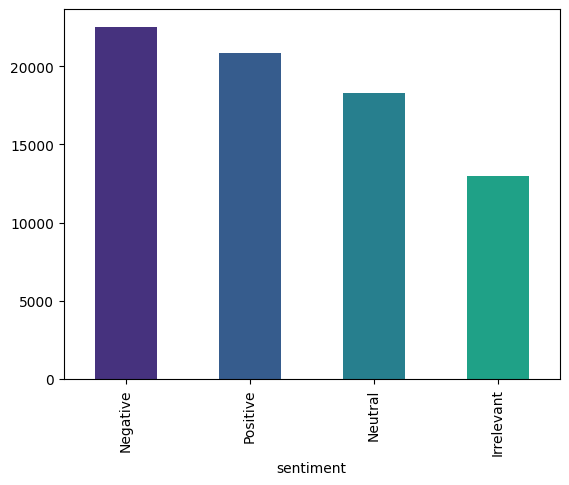

In [5]:
df["sentiment"].value_counts().plot(kind="bar", color=sns.color_palette("viridis"))
plt.show()

In [6]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 74681 entries, 0 to 74680
Data columns (total 4 columns):
 #   Column      Non-Null Count  Dtype 
---  ------      --------------  ----- 
 0   tweet_id    74681 non-null  int64 
 1   entity      74681 non-null  object
 2   sentiment   74681 non-null  object
 3   tweet_text  73823 non-null  object
dtypes: int64(1), object(3)
memory usage: 2.3+ MB


# Tweet text structural distribution


In [7]:
df["tweet_length"] = df["tweet_text"].astype(str).apply(len)
df["word_count"]   = df["tweet_text"].astype(str).apply(lambda x: len(x.split()))

print(df[["tweet_length", "word_count"]].describe().round(1))

       tweet_length  word_count
count       74681.0     74681.0
mean          107.7        19.1
std            79.8        14.5
min             1.0         1.0
25%            45.0         8.0
50%            90.0        15.0
75%           152.0        27.0
max           957.0       198.0


In [8]:
df.head()

,tweet_id,entity,sentiment,tweet_text,tweet_length,word_count
0,2401,Borderlands,Positive,I am coming to the borders and I will kill you...,51,12
1,2401,Borderlands,Positive,im getting on borderlands and i will kill you ...,50,10
2,2401,Borderlands,Positive,im coming on borderlands and i will murder you...,51,10
3,2401,Borderlands,Positive,im getting on borderlands 2 and i will murder ...,57,12
4,2401,Borderlands,Positive,im getting into borderlands and i can murder y...,53,10


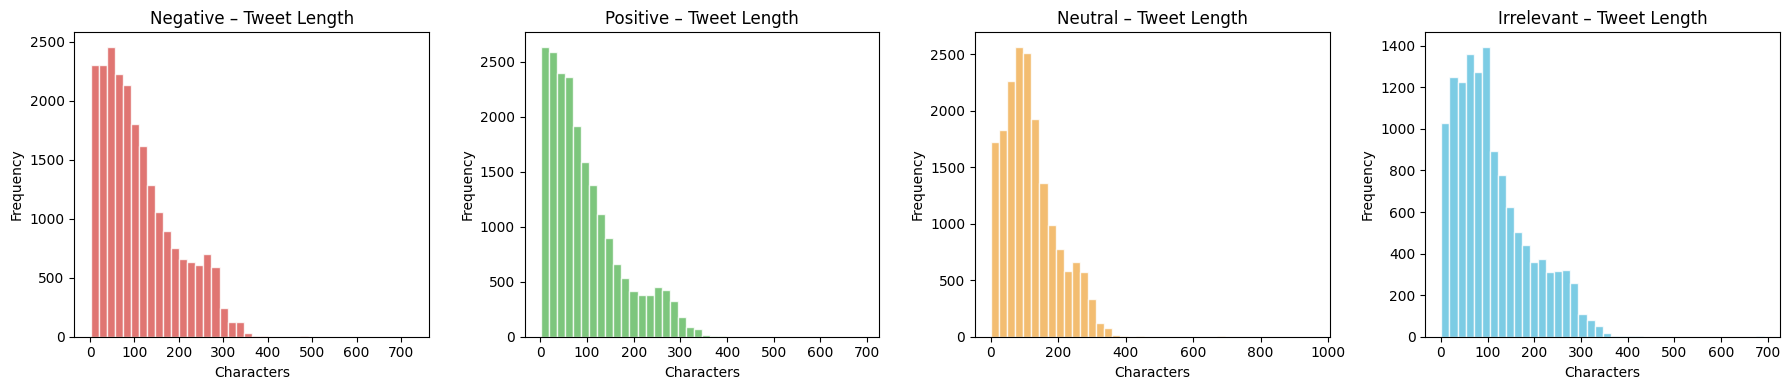

In [11]:
fig, axes = plt.subplots(1, 4, figsize=(18, 4))

for label, color, ax, col in zip(
    ["Negative", "Positive", "Neutral", "Irrelevant"],
    ["#d9534f", "#5cb85c", "#f0ad4e", "#5bc0de"], 
    axes,
    ['Negative', 'Positive', 'Neutral', 'Irrelevant'] 
):
    data = df[df["sentiment"] == col]["tweet_length"]
    ax.hist(data, bins=40, color=color, edgecolor="white", alpha=0.8)
    ax.set_title(f"{label} – Tweet Length")
    ax.set_xlabel("Characters")
    ax.set_ylabel("Frequency")

plt.tight_layout()
plt.show()

In [15]:
df["sentiment"].value_counts()

sentiment
Negative      22542
Positive      20831
Neutral       18318
Irrelevant    12990
Name: count, dtype: int64

# convert text lists based on category.

In [16]:
neg = list(df[df["sentiment"]=="Negative"]["tweet_text"])
pos = list(df[df["sentiment"]=="Positive"]["tweet_text"])
neutral =list(df[df["sentiment"]=="Neutral"]["tweet_text"])
irrelevant = list(df[df["sentiment"]=="Irrelevant"]["tweet_text"])

# Removing Noise

In [17]:
stop_word = stopwords.words("english")

In [ ]:
def generate_wordcloud(tweet_text, title= " "):
    """
    Generates and displays a word cloud from a given string of text.
    """
    # Create the word cloud object with custom parameters
    wc = WordCloud(
        width=800, 
        height=400, 
        background_color='white', 
        stopwords=stop_word, 
        min_font_size=10
    ).generate(tweet_text)

    # Plotting the word cloud
    plt.figure(figsize=(10, 5))
    plt.imshow(wc, interpolation='bilinear')
    plt.axis("off")  
    plt.title(title, fontsize=20)

    plt.show()

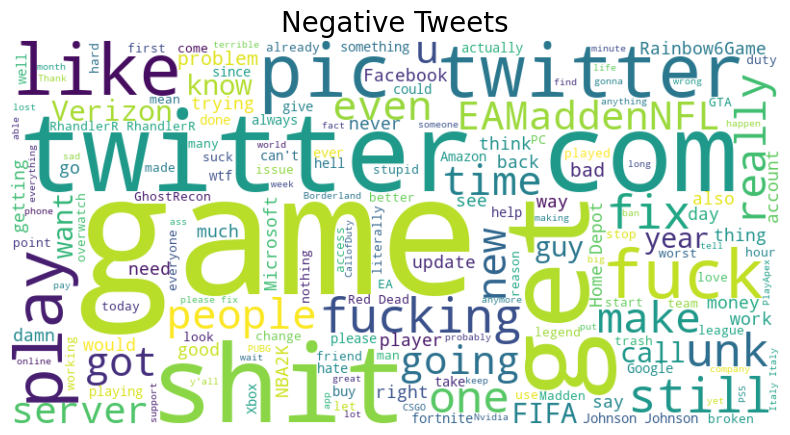

In [20]:
# generate_wordcloud(" ".join(neg), "Negative")
generate_wordcloud(" ".join([str(tweet) for tweet in neg]), "Negative Tweets")

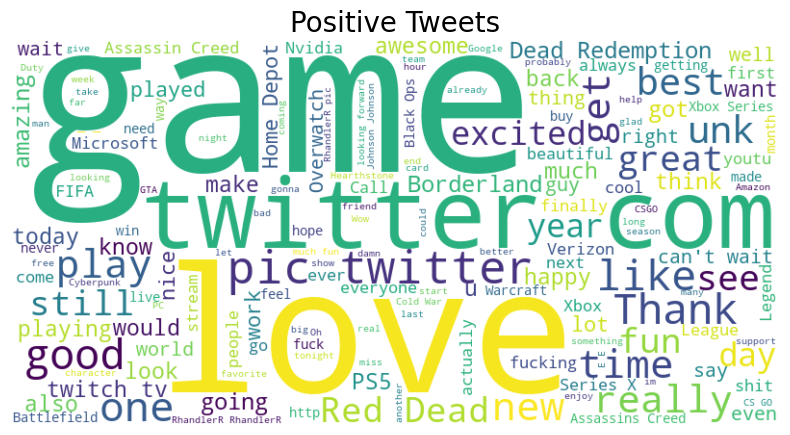

In [21]:
generate_wordcloud(" ".join([str(tweet) for tweet in pos]), "Positive Tweets")

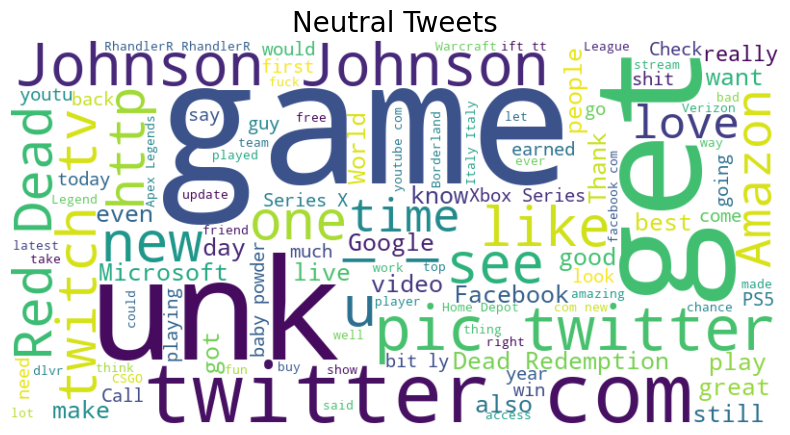

In [22]:
generate_wordcloud(" ".join([str(tweet) for tweet in neutral]), "Neutral Tweets")

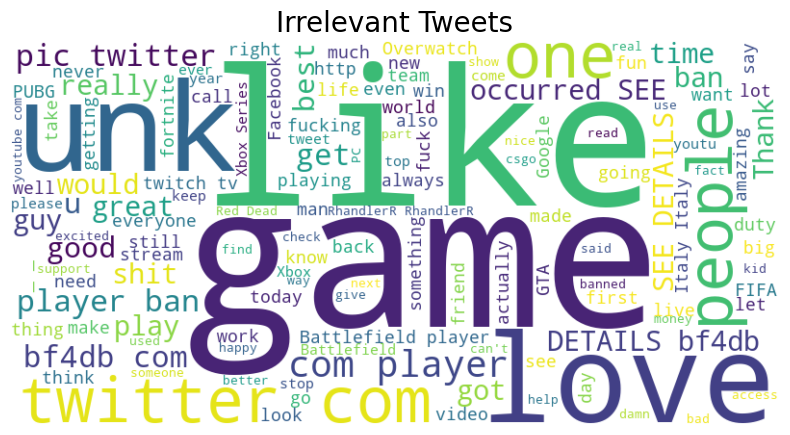

In [23]:
generate_wordcloud(" ".join([str(tweet) for tweet in irrelevant]), "Irrelevant Tweets")

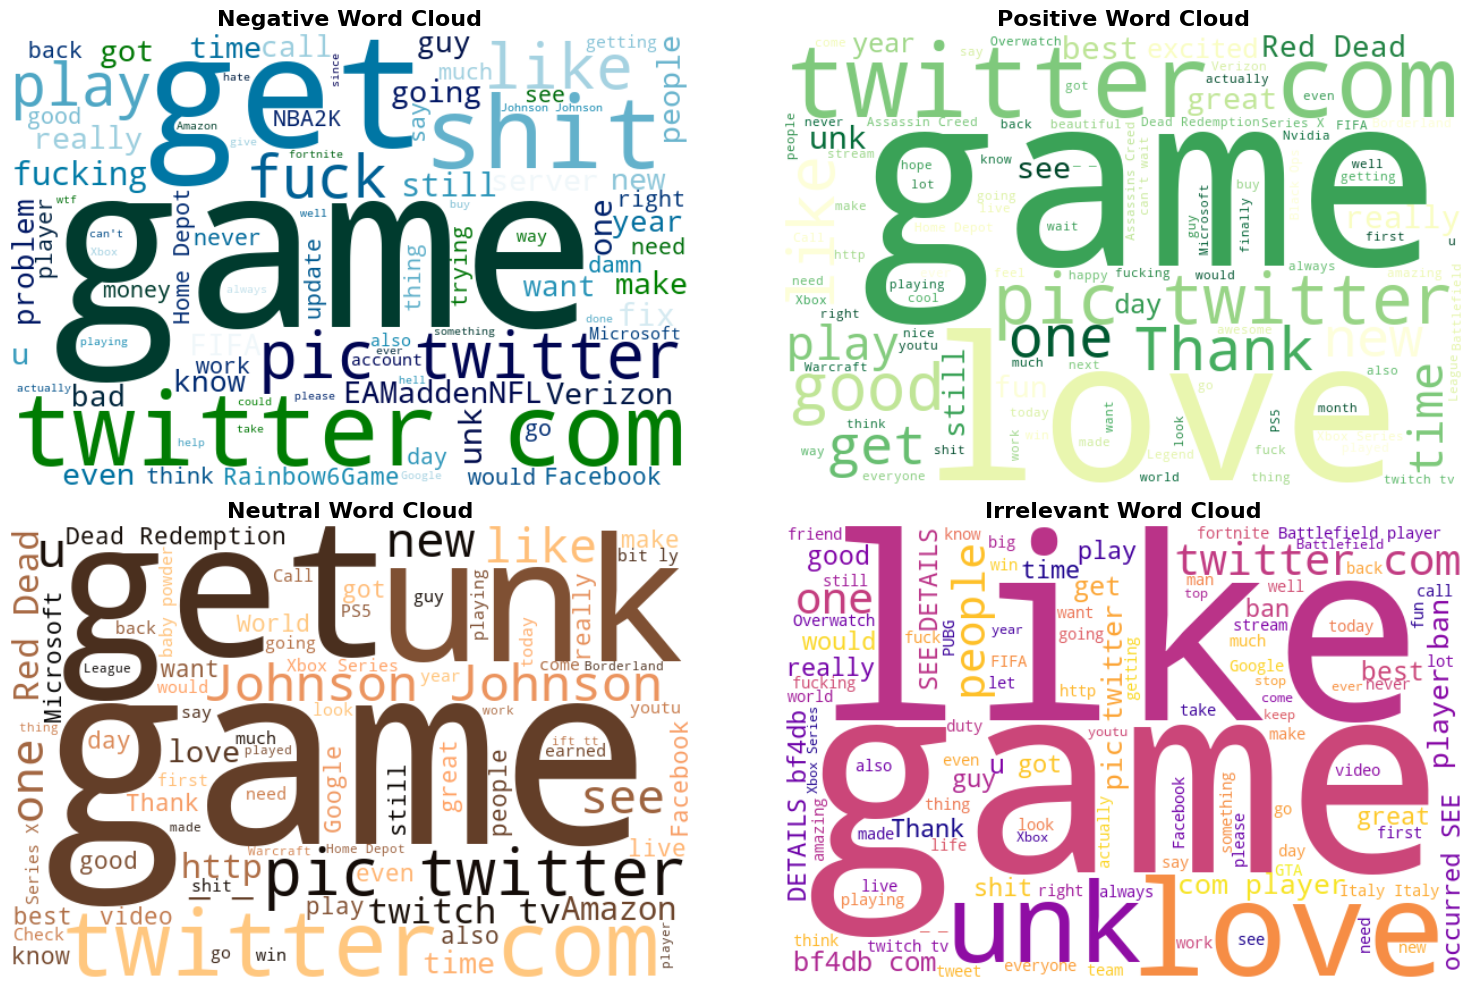

In [30]:
import matplotlib.pyplot as plt

# 1. Package your text data arrays into a collection matching their labels
sentiment_data = {
    "Negative": " ".join([str(t) for t in neg]),
    "Positive": " ".join([str(t) for t in pos]),
    "Neutral": " ".join([str(t) for t in neutral]),
    "Irrelevant": " ".join([str(t) for t in irrelevant])
}

# 2. Match them to the distinct color schemes we used earlier
color_maps = {
    "Negative": "ocean",
    "Positive": "YlGn",
    "Neutral": "copper",
    "Irrelevant": "plasma"
}

# 3. Create a 2x2 grid container
fig, axes = plt.subplots(2, 2, figsize=(16, 10))
axes = axes.flatten() # Flattens into a 1D list for seamless looping

# 4. Generate and plot inside the subplots
for ax, (label, text) in zip(axes, sentiment_data.items()):
    wc = WordCloud(
        width=600, 
        height=400, 
        background_color='white', 
        stopwords=stop_word, 
        min_font_size=10,
        colormap=color_maps[label] # Sets matching themed colors
    ).generate(text)
    
    ax.imshow(wc, interpolation='bilinear')
    ax.axis("off")
    ax.set_title(f"{label} Word Cloud", fontsize=16, fontweight='bold')

plt.tight_layout()
plt.show()

# reduce words down to their base

In [33]:
word_lmma = WordNetLemmatizer()

In [34]:
def preprocess(text):
    token = str(text)
    rem_pun= re.sub(r'[^\w\s]', '',token)
    clean_num= re.sub(r'\d+', '', rem_pun)
    spea_remove = re.sub(r'[^A-Za-z0-9\s]', '', clean_num)
    clean_contraction= re.sub(r"luv", "love", spea_remove)
    clean_contraction= re.sub(r"can't" , "cannot", clean_contraction)

    tokens = word_tokenize(clean_contraction)
    processed_tokens = [word_lmma.lemmatize(word.lower()) for word in tokens if word.isalpha() and word not in stop_word] # spacy use kore korben 

    return " ".join(processed_tokens) 

In [38]:
df["clean_text"]= df["tweet_text"].apply(preprocess)

In [39]:
df.head()

,tweet_id,entity,sentiment,tweet_text,tweet_length,word_count,clean_text
0,2401,Borderlands,Positive,I am coming to the borders and I will kill you...,51,12,i coming border i kill
1,2401,Borderlands,Positive,im getting on borderlands and i will kill you ...,50,10,im getting borderland kill
2,2401,Borderlands,Positive,im coming on borderlands and i will murder you...,51,10,im coming borderland murder
3,2401,Borderlands,Positive,im getting on borderlands 2 and i will murder ...,57,12,im getting borderland murder
4,2401,Borderlands,Positive,im getting into borderlands and i can murder y...,53,10,im getting borderland murder


In [40]:
neg_cl = list(df[df["sentiment"]=="Negative"]["clean_text"])
pos_cl = list(df[df["sentiment"]=="Positive"]["clean_text"])
neutral_cl =list(df[df["sentiment"]=="Neutral"]["clean_text"])
irrelevant_cl = list(df[df["sentiment"]=="Irrelevant"]["clean_text"])

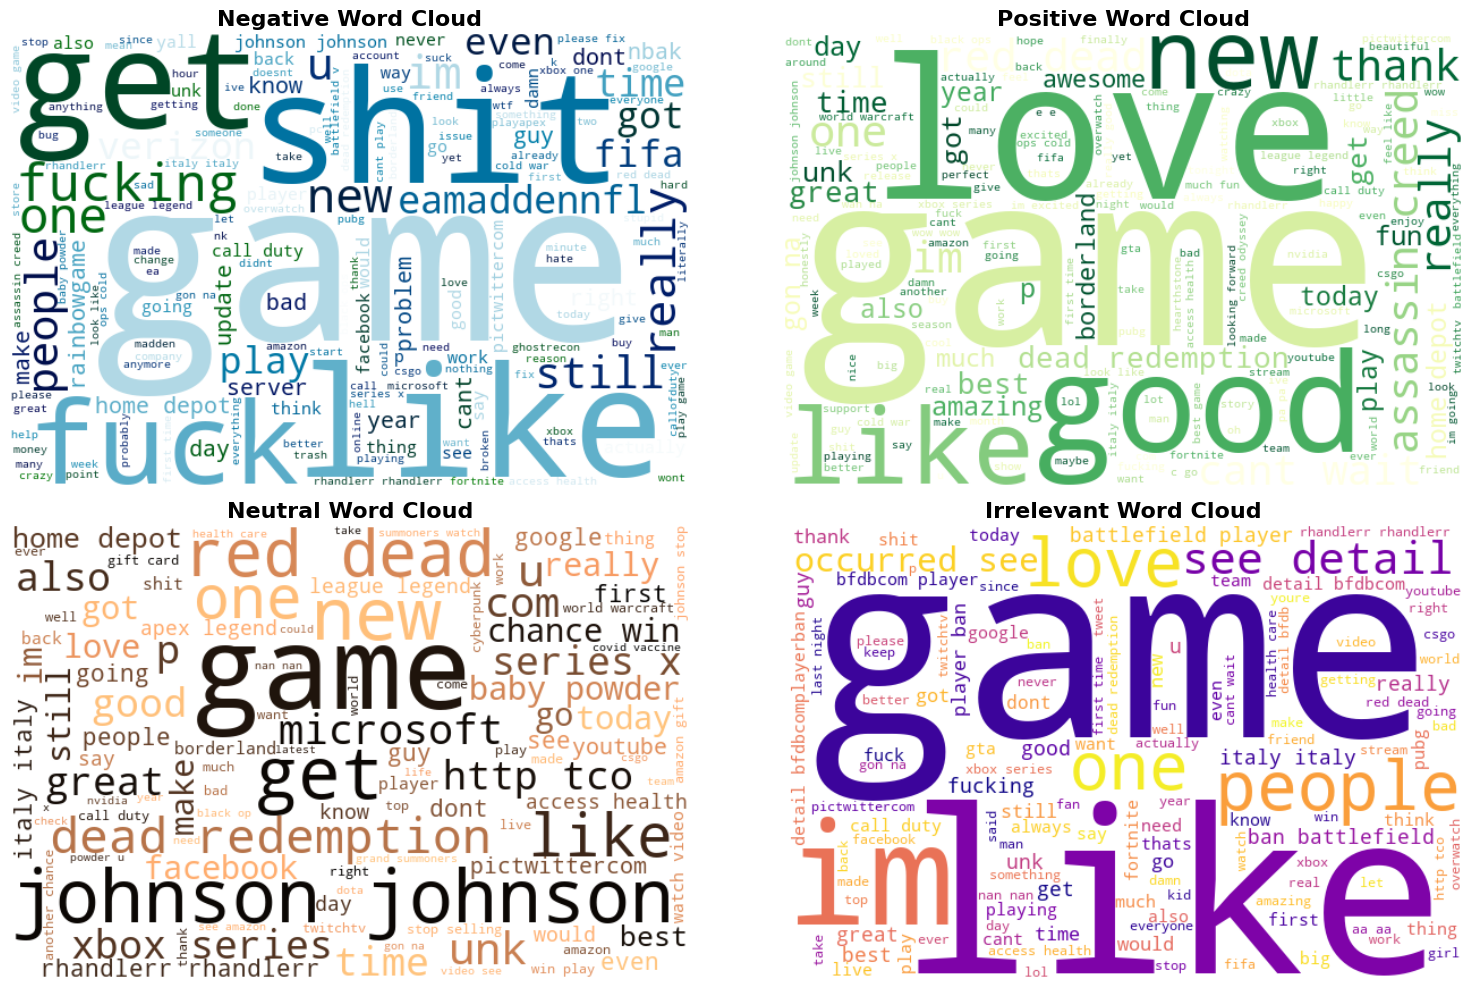

In [41]:
import matplotlib.pyplot as plt

# 1. Package your text data arrays into a collection matching their labels
sentiment_data = {
    "Negative": " ".join([str(t) for t in neg_cl]),
    "Positive": " ".join([str(t) for t in pos_cl]),
    "Neutral": " ".join([str(t) for t in neutral_cl]),
    "Irrelevant": " ".join([str(t) for t in irrelevant_cl])
}

# 2. Match them to the distinct color schemes we used earlier
color_maps = {
    "Negative": "ocean",
    "Positive": "YlGn",
    "Neutral": "copper",
    "Irrelevant": "plasma"
}

# 3. Create a 2x2 grid container
fig, axes = plt.subplots(2, 2, figsize=(16, 10))
axes = axes.flatten() # Flattens into a 1D list for seamless looping

# 4. Generate and plot inside the subplots
for ax, (label, text) in zip(axes, sentiment_data.items()):
    wc = WordCloud(
        width=600, 
        height=400, 
        background_color='white', 
        stopwords=stop_word, 
        min_font_size=10,
        colormap=color_maps[label] # Sets matching themed colors
    ).generate(text)
    
    ax.imshow(wc, interpolation='bilinear')
    ax.axis("off")
    ax.set_title(f"{label} Word Cloud", fontsize=16, fontweight='bold')

plt.tight_layout()
plt.show()

# checking dataset

In [42]:
df.head()

,tweet_id,entity,sentiment,tweet_text,tweet_length,word_count,clean_text
0,2401,Borderlands,Positive,I am coming to the borders and I will kill you...,51,12,i coming border i kill
1,2401,Borderlands,Positive,im getting on borderlands and i will kill you ...,50,10,im getting borderland kill
2,2401,Borderlands,Positive,im coming on borderlands and i will murder you...,51,10,im coming borderland murder
3,2401,Borderlands,Positive,im getting on borderlands 2 and i will murder ...,57,12,im getting borderland murder
4,2401,Borderlands,Positive,im getting into borderlands and i can murder y...,53,10,im getting borderland murder


# Features and Labels Split

In [43]:
x = df["clean_text"]
y = df["sentiment"]

In [44]:
x.shape

(74681,)

In [45]:
y.shape

(74681,)

In [47]:
lr = LabelEncoder()
y = lr.fit_transform(y)

In [48]:
xtrain, xtest, ytrain, ytest = train_test_split(x,y, test_size=.2, random_state = 42)

In [49]:
xtrain.shape

(59744,)

In [50]:
xtest.shape

(14937,)

# vector format 

In [53]:
count_vec = CountVectorizer(max_features=1000000)
xtrain_vec= count_vec.fit_transform(xtrain)
xtrain_vec

<Compressed Sparse Row sparse matrix of dtype 'int64'
	with 635609 stored elements and shape (59744, 33462)>

In [ ]:
# vectorizer = TfidfVectorizer(max_features=1000000)
# xtrain_vec = vectorizer.fit_transform(xtrain)
# xtrain_vec
# xtest_vec = vectorizer.transform(xtest)

In [54]:
xtrain_vec.shape

(59744, 33462)

In [64]:
xtest_vec = count_vec.transform(xtest)
xtest_vec.shape

(14937, 33462)

# DecisionTreeClassifier

In [84]:
dt =  DecisionTreeClassifier()
model1 = dt.fit(xtrain_vec, ytrain)

In [85]:
model1.score(xtrain_vec, ytrain)

0.9716791644349223

In [86]:
xtest_vec= count_vec.transform(xtest)
xtest_vec.shape

(14937, 33462)

In [87]:
model1.score(xtest_vec, ytest)

0.8043114413871594

In [88]:
y_pred1 = model1.predict(xtest_vec)

In [89]:
print(classification_report(ytest, y_pred1))

              precision    recall  f1-score   support

           0       0.81      0.75      0.78      2661
           1       0.84      0.82      0.83      4471
           2       0.79      0.79      0.79      3551
           3       0.77      0.83      0.80      4254

    accuracy                           0.80     14937
   macro avg       0.80      0.80      0.80     14937
weighted avg       0.81      0.80      0.80     14937



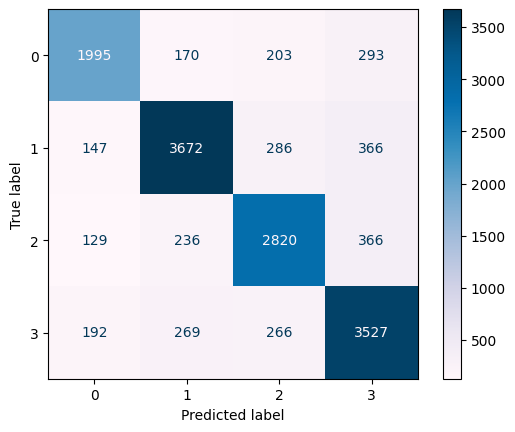

In [91]:
from sklearn.metrics import confusion_matrix, ConfusionMatrixDisplay
cm = confusion_matrix(ytest, y_pred1, labels=model1.classes_)
disp = ConfusionMatrixDisplay(confusion_matrix=cm, display_labels=model1.classes_)
disp.plot(cmap="PuBu")

# model save 

In [92]:

pickle.dump(model, open("dt_model.pkl","wb"))

# vector model save

In [71]:
pickle.dump(count_vec, open("vec_model.pkl","wb"))

# MultinomialNaiveBayes

In [72]:
nb = MultinomialNB(alpha=1.0)
model2 = nb.fit(xtrain_vec, ytrain)

In [73]:
model2.score(xtrain_vec, ytrain)

0.7885310658810927

In [74]:
model2.score(xtest_vec, ytest)

0.7330789315123519

In [75]:
y_pred2 = model2.predict(xtest_vec)

In [76]:
print(classification_report(ytest, y_pred2))

              precision    recall  f1-score   support

           0       0.83      0.59      0.69      2661
           1       0.70      0.84      0.77      4471
           2       0.77      0.63      0.69      3551
           3       0.70      0.80      0.75      4254

    accuracy                           0.73     14937
   macro avg       0.75      0.71      0.72     14937
weighted avg       0.74      0.73      0.73     14937



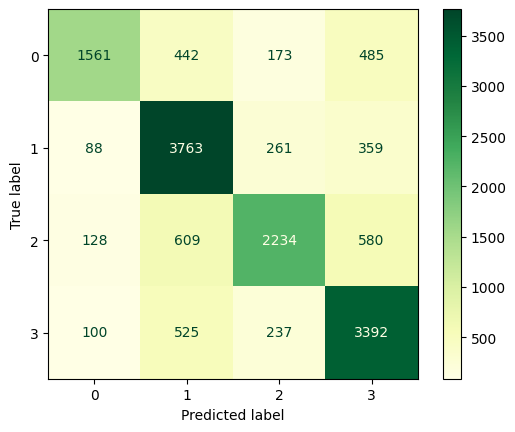

In [77]:
from sklearn.metrics import confusion_matrix, ConfusionMatrixDisplay
cm = confusion_matrix(ytest, y_pred2, labels=model1.classes_)
disp = ConfusionMatrixDisplay(confusion_matrix=cm, display_labels=model2.classes_)
disp.plot(cmap="YlGn")

# Save Model

In [79]:
pickle.dump(model, open("nb_model.pkl","wb"))

# LogisticRegression

In [94]:
lr = LogisticRegression()
model3 = lr.fit(xtrain_vec, ytrain)

c:\Users\Windows 11-Pro Edu\AppData\Local\Programs\Python\Python313\Lib\site-packages\sklearn\linear_model\_logistic.py:406: ConvergenceWarning: lbfgs failed to converge after 100 iteration(s) (status=1):
STOP: TOTAL NO. OF ITERATIONS REACHED LIMIT

Increase the number of iterations to improve the convergence (max_iter=100).
You might also want to scale the data as shown in:
    https://scikit-learn.org/stable/modules/preprocessing.html
Please also refer to the documentation for alternative solver options:
    https://scikit-learn.org/stable/modules/linear_model.html#logistic-regression
  n_iter_i = _check_optimize_result(


In [95]:
model3.score(xtrain_vec, ytrain)

0.8863651580074987

In [96]:
model3.score(xtest_vec, ytest)

0.797281917386356

In [97]:
y_pred3 = model3.predict(xtest_vec)

In [98]:
print(classification_report(ytest, y_pred3))

              precision    recall  f1-score   support

           0       0.83      0.71      0.76      2661
           1       0.83      0.84      0.83      4471
           2       0.79      0.76      0.78      3551
           3       0.76      0.83      0.80      4254

    accuracy                           0.80     14937
   macro avg       0.80      0.79      0.79     14937
weighted avg       0.80      0.80      0.80     14937



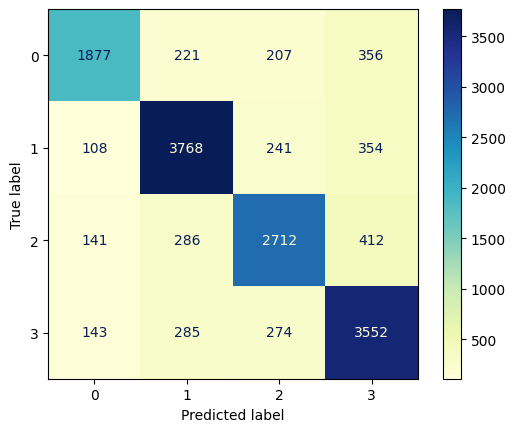

In [99]:
from sklearn.metrics import confusion_matrix, ConfusionMatrixDisplay
cm = confusion_matrix(ytest, y_pred3, labels=model1.classes_)
disp = ConfusionMatrixDisplay(confusion_matrix=cm, display_labels=model3.classes_)
disp.plot(cmap="YlGnBu")

In [100]:
pickle.dump(model3, open("lr_model.pkl","wb"))

# LinearSVC

In [101]:
svm = LinearSVC(C=0.2, random_state=42)
model4 = svm.fit(xtrain_vec, ytrain)

In [102]:
model4.score(xtrain_vec, ytrain)

0.9072208087841457

In [103]:
model4.score(xtest_vec, ytest)

0.8254669612371962

In [104]:
y_pred4 = model4.predict(xtest_vec)

In [105]:
print(classification_report(ytest, y_pred4))

              precision    recall  f1-score   support

           0       0.88      0.75      0.81      2661
           1       0.84      0.86      0.85      4471
           2       0.83      0.80      0.81      3551
           3       0.78      0.86      0.82      4254

    accuracy                           0.83     14937
   macro avg       0.83      0.82      0.82     14937
weighted avg       0.83      0.83      0.83     14937



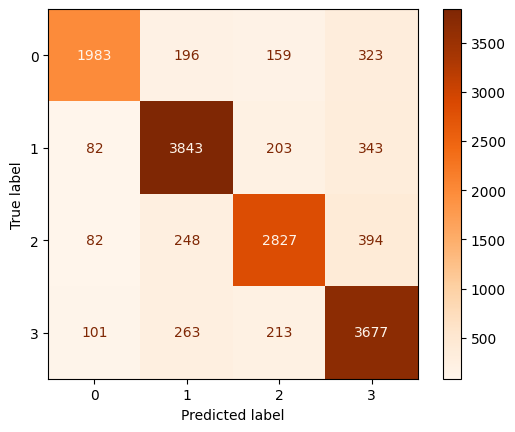

In [108]:
from sklearn.metrics import confusion_matrix, ConfusionMatrixDisplay
cm = confusion_matrix(ytest, y_pred4, labels=model4.classes_)
disp = ConfusionMatrixDisplay(confusion_matrix=cm, display_labels=model4.classes_)
disp.plot(cmap="Oranges")

In [109]:
pickle.dump(model4, open("svm_model.pkl","wb"))

In [ ]:
compair 

In [111]:
# 1. Print all train and test scores sequentially
print("--- Model 1: Naive Bayes ---")
print("Train Score:", model1.score(xtrain_vec, ytrain))
print("Test Score :", model1.score(xtest_vec, ytest))
print()

print("--- Model 2: Decision Tree ---")
print("Train Score:", model2.score(xtrain_vec, ytrain))
print("Test Score :", model2.score(xtest_vec, ytest))
print()

print("--- Model 3: Logistic Regression ---")
print("Train Score:", model3.score(xtrain_vec, ytrain))
print("Test Score :", model3.score(xtest_vec, ytest))
print()

print("--- Model 4: Linear SVM ---")
print("Train Score:", model4.score(xtrain_vec, ytrain))
print("Test Score :", model4.score(xtest_vec, ytest)) 

--- Model 1: Naive Bayes ---
Train Score: 0.9716791644349223
Test Score : 0.8043114413871594

--- Model 2: Decision Tree ---
Train Score: 0.7885310658810927
Test Score : 0.7330789315123519

--- Model 3: Logistic Regression ---
Train Score: 0.8863651580074987
Test Score : 0.797281917386356

--- Model 4: Linear SVM ---
Train Score: 0.9072208087841457
Test Score : 0.8254669612371962
